In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pydotplus
import plotly.graph_objects as go
import warnings
warnings.simplefilter(action="ignore")

# 1. Load the Data

In [29]:
#--------- load the data -----------

url = '/kaggle/input/datasets/aithocinekhadidja/telecom-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(url)

In [30]:
#-------------- display options --------------
pd.set_option('display.max_columns' , None)
pd.set_option('display.width' , 1000)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# 2. Global informations about the data

In [31]:
#------------- Data overview ------------
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [32]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


# 3.Check The Format of The Data and transforme if necessary

In [33]:
# we have 3 columns with wrong format :
# SeniorCitizen (int) --> (object)
# TotalCharges (object) --> (float)
# Churn (object Yes/No) --> (object 1/0)
df['SeniorCitizen'] = df['SeniorCitizen'].astype("O")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'] , errors = 'coerce')
df['Churn'] = df['Churn'].apply(lambda x : 1 if x == 'Yes' else 0)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.850,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.500,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.150,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.750,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.650,1


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# 4. Classify The Data into Numerical and Categorical Columns

In [35]:
#------- Classify the data -----------

cat_columns = ['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

num_cal = ['tenure', 'MonthlyCharges', 'TotalCharges']



# 5. Analysing Categorical Data

        gender  Ratio
gender               
Male      3555 50.476
Female    3488 49.524


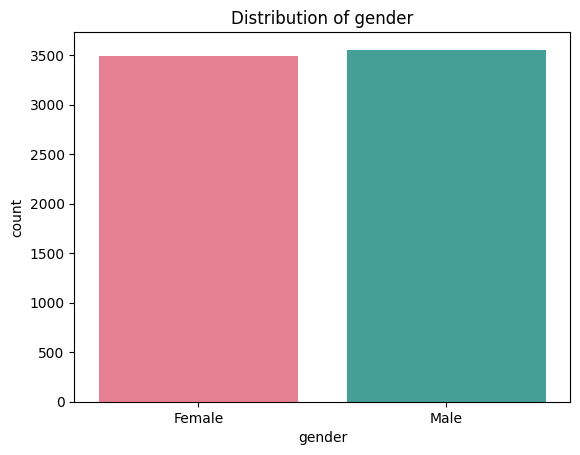

               SeniorCitizen  Ratio
SeniorCitizen                      
0                       5901 83.785
1                       1142 16.215


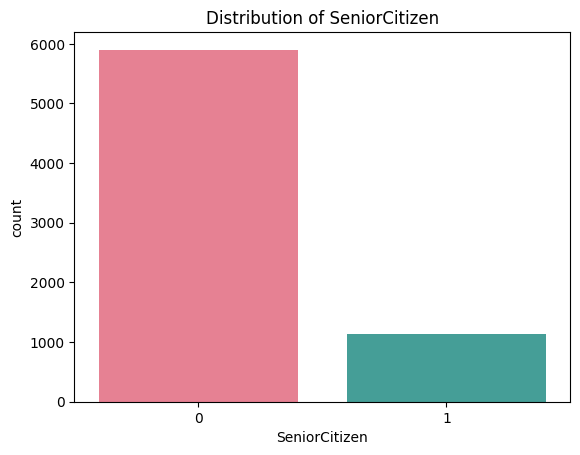

         Partner  Ratio
Partner                
No          3641 51.697
Yes         3402 48.303


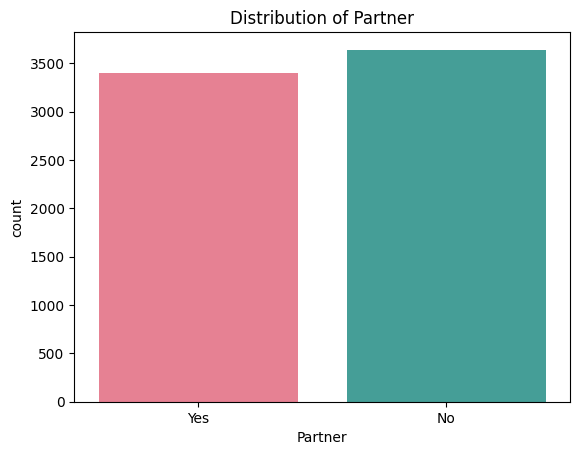

            Dependents  Ratio
Dependents                   
No                4933 70.041
Yes               2110 29.959


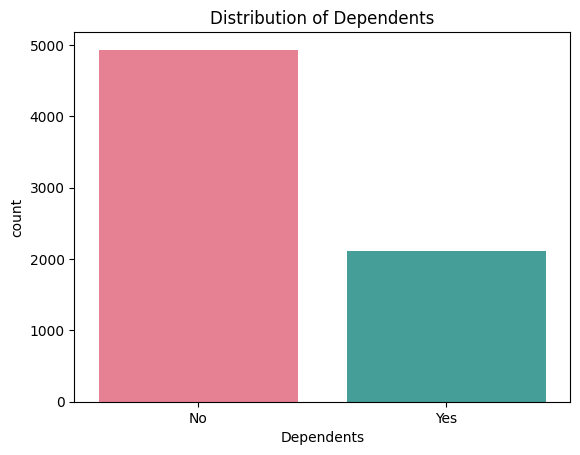

              PhoneService  Ratio
PhoneService                     
Yes                   6361 90.317
No                     682  9.683


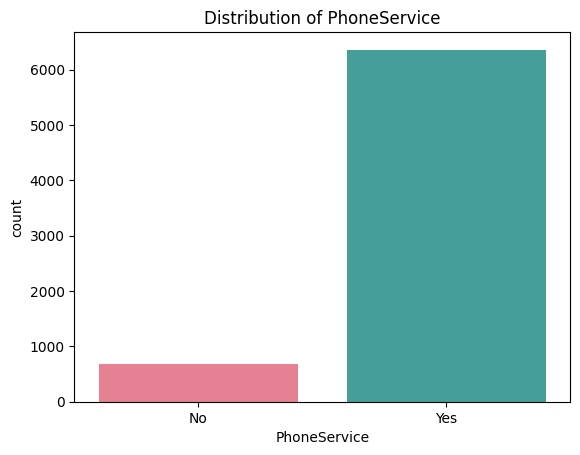

                  MultipleLines  Ratio
MultipleLines                         
No                         3390 48.133
Yes                        2971 42.184
No phone service            682  9.683


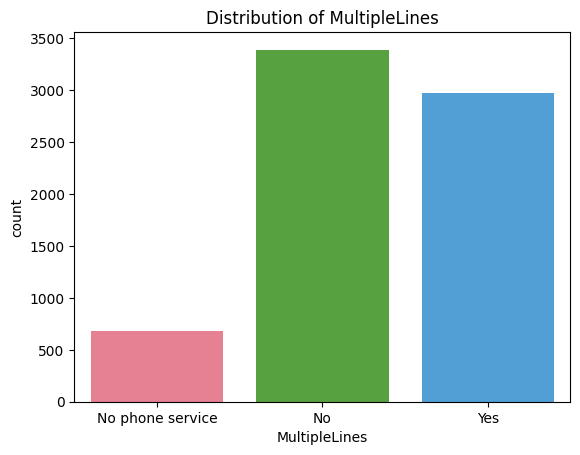

                 InternetService  Ratio
InternetService                        
Fiber optic                 3096 43.959
DSL                         2421 34.375
No                          1526 21.667


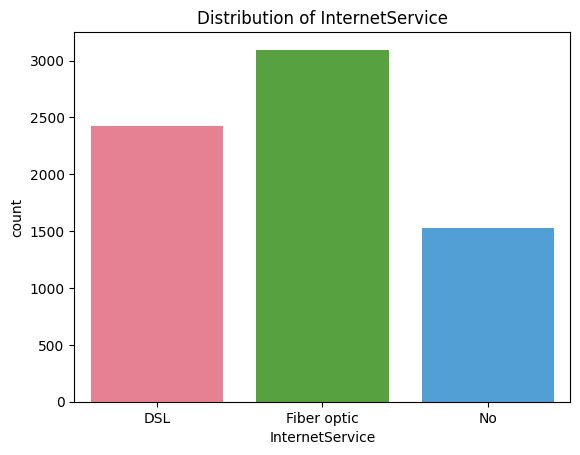

                     OnlineSecurity  Ratio
OnlineSecurity                            
No                             3498 49.666
Yes                            2019 28.667
No internet service            1526 21.667


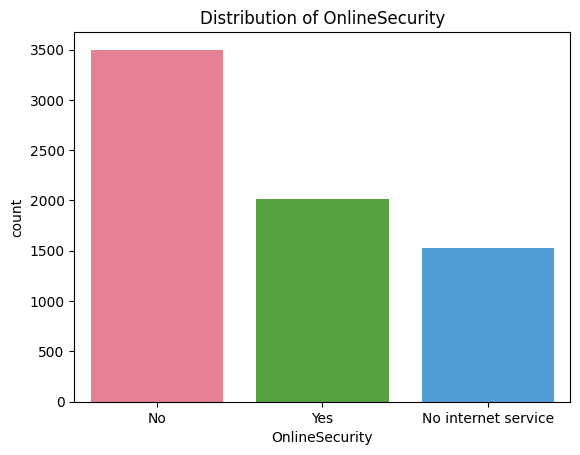

                     OnlineBackup  Ratio
OnlineBackup                            
No                           3088 43.845
Yes                          2429 34.488
No internet service          1526 21.667


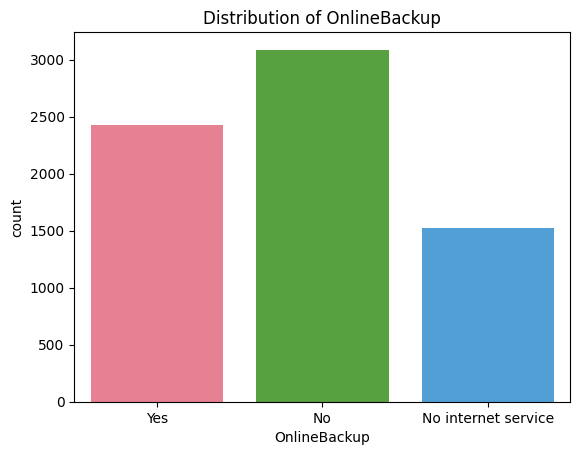

                     DeviceProtection  Ratio
DeviceProtection                            
No                               3095 43.944
Yes                              2422 34.389
No internet service              1526 21.667


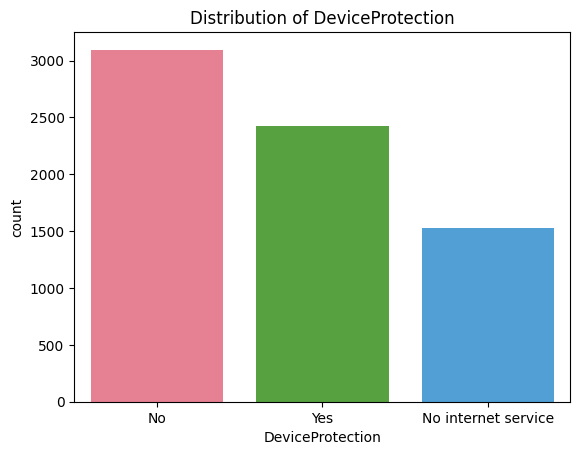

                     TechSupport  Ratio
TechSupport                            
No                          3473 49.311
Yes                         2044 29.022
No internet service         1526 21.667


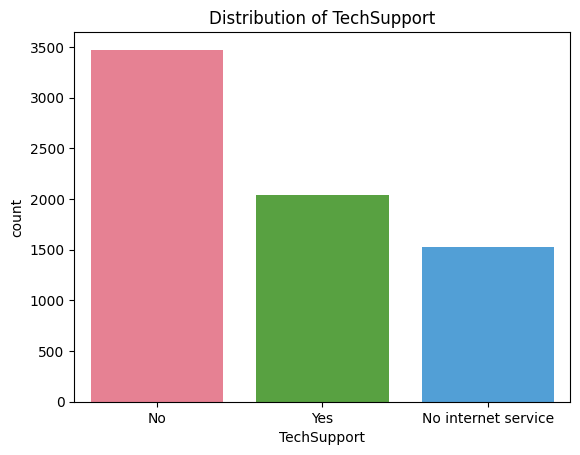

                     StreamingTV  Ratio
StreamingTV                            
No                          2810 39.898
Yes                         2707 38.435
No internet service         1526 21.667


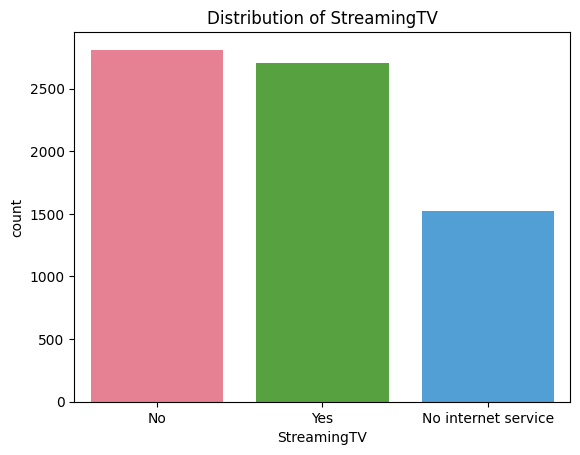

                     StreamingMovies  Ratio
StreamingMovies                            
No                              2785 39.543
Yes                             2732 38.790
No internet service             1526 21.667


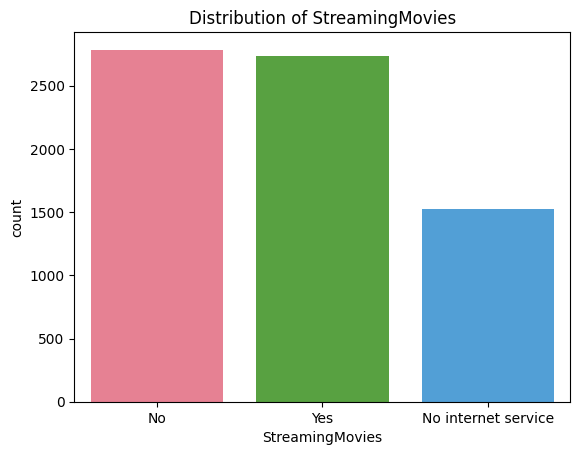

                Contract  Ratio
Contract                       
Month-to-month      3875 55.019
Two year            1695 24.066
One year            1473 20.914


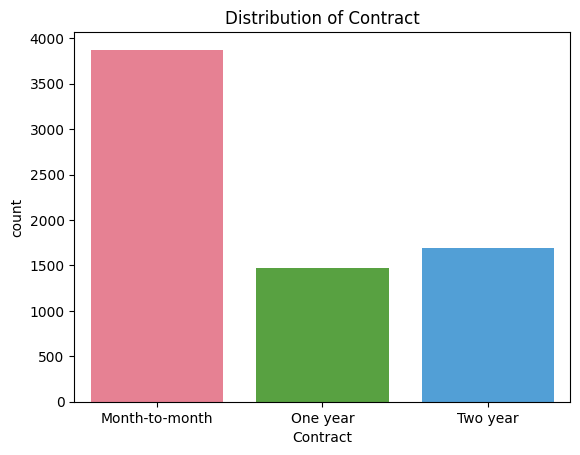

                  PaperlessBilling  Ratio
PaperlessBilling                         
Yes                           4171 59.222
No                            2872 40.778


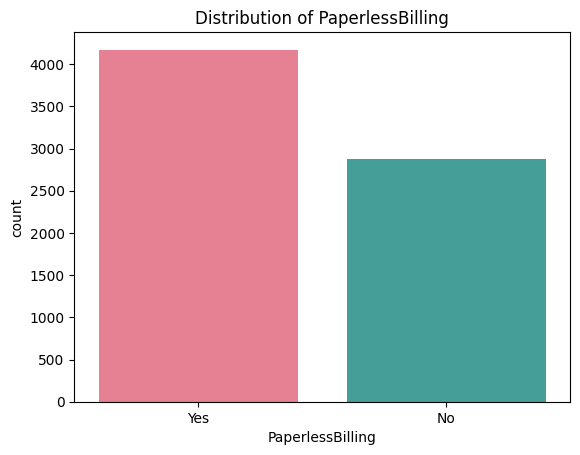

                           PaymentMethod  Ratio
PaymentMethod                                  
Electronic check                    2365 33.579
Mailed check                        1612 22.888
Bank transfer (automatic)           1544 21.922
Credit card (automatic)             1522 21.610


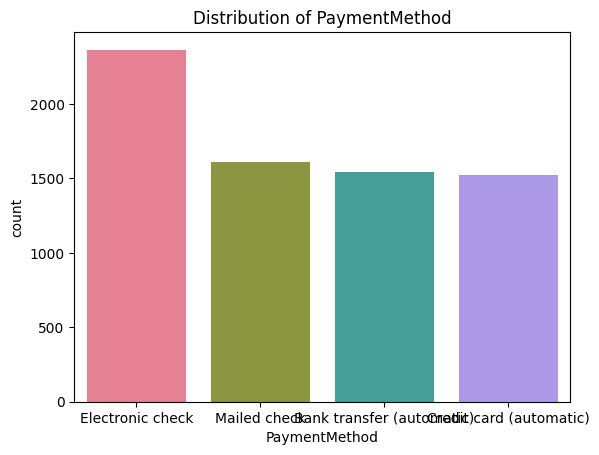

       Churn  Ratio
Churn              
0       5174 73.463
1       1869 26.537


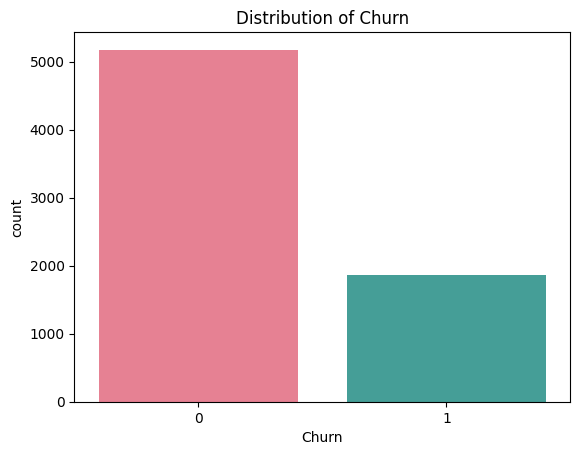

In [36]:
def cat_summery (df , col , plot=False):
    print(pd.DataFrame({col: df[col].value_counts(),
                        "Ratio": df[col].value_counts() * 100 / len(df) 
                       } 
                      )
         )
    if plot:
        sns.countplot(x=df[col] , data=df , palette="husl" )
        plt.title(f"Distribution of {col}")
        plt.show()
        
for col in cat_columns:
    cat_summery(df , col , plot=True)


# 6. Analysing Numerical Data

In [37]:
df.describe()

,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000,7043.000,7032.000,7043.000
mean,32.371,64.762,2283.300,0.265
std,24.559,30.090,2266.771,0.442
min,0.000,18.250,18.800,0.000
25%,9.000,35.500,401.450,0.000
50%,29.000,70.350,1397.475,0.000
75%,55.000,89.850,3794.738,1.000
max,72.000,118.750,8684.800,1.000


count   7043.000
mean      32.371
std       24.559
min        0.000
5%         1.000
10%        2.000
20%        6.000
30%       12.000
40%       20.000
50%       29.000
60%       40.000
70%       50.000
80%       60.000
90%       69.000
95%       72.000
99%       72.000
max       72.000
Name: tenure, dtype: float64


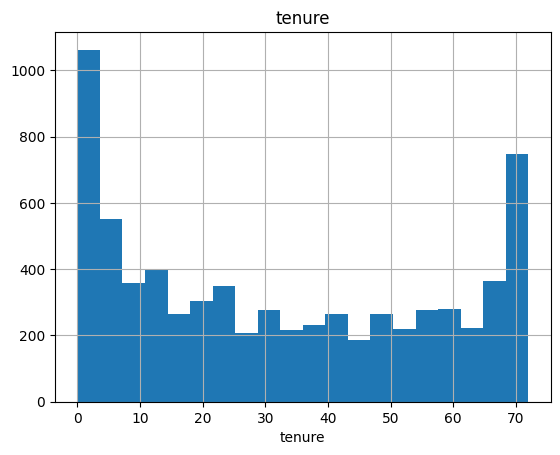

count   7043.000
mean      64.762
std       30.090
min       18.250
5%        19.650
10%       20.050
20%       25.050
30%       45.850
40%       58.830
50%       70.350
60%       79.100
70%       85.500
80%       94.250
90%      102.600
95%      107.400
99%      114.729
max      118.750
Name: MonthlyCharges, dtype: float64


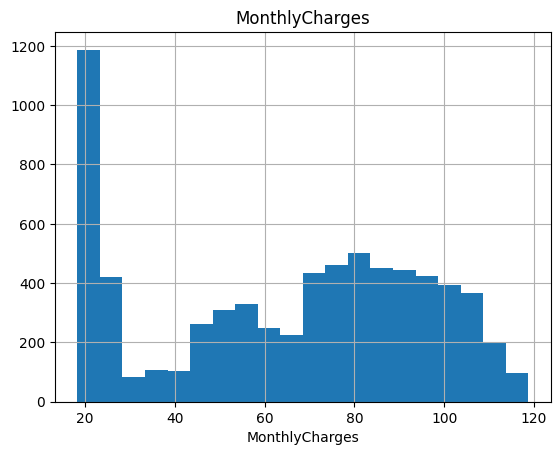

count   7032.000
mean    2283.300
std     2266.771
min       18.800
5%        49.605
10%       84.600
20%      267.070
30%      551.995
40%      944.170
50%     1397.475
60%     2048.950
70%     3141.130
80%     4475.410
90%     5976.640
95%     6923.590
99%     8039.883
max     8684.800
Name: TotalCharges, dtype: float64


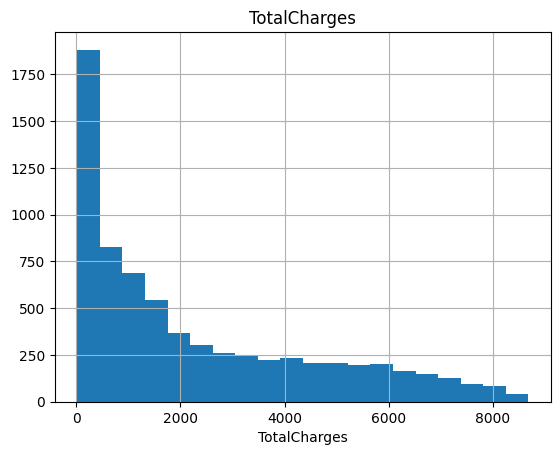

In [38]:
# where data concentrate ( quantiles )
def num_summary(df, num_col, plot=False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(df[num_col].describe(quantiles).T)
    if plot:
        df[num_col].hist(bins=20)
        plt.xlabel(num_col)
        plt.title(num_col)
        plt.show(block=True)


for col in num_cal:
    num_summary(df, col, plot=True)

**The TotalCharges has positive skewness and 11 nul value , other column seems normal** 

there are lot of new client for this reason we have a tall bar in 0 ( actually not zero but the bin is to small so all values under 450 seems to be zero)

# 7. Detecting Null Values and Adjusting it

In [39]:
# detecting outliers and null values 
df["TotalCharges"].isnull().sum()

np.int64(11)

In [40]:
df[df["TotalCharges"].isnull()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.550,NaN
753,3115-CZMZD,0,20.250,NaN
936,5709-LVOEQ,0,80.850,NaN
1082,4367-NUYAO,0,25.750,NaN
1340,1371-DWPAZ,0,56.050,NaN
3331,7644-OMVMY,0,19.850,NaN
3826,3213-VVOLG,0,25.350,NaN
4380,2520-SGTTA,0,20.000,NaN
5218,2923-ARZLG,0,19.700,NaN
6670,4075-WKNIU,0,73.350,NaN


**since tenure 0 so all clients are new , they leave before ending the month , so the TotalCharges is just the MonthCharges**

In [41]:
# detecting outliers and null values 
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"])

In [42]:

df["TotalCharges"].isnull().sum()

np.int64(0)

# 8. Outliers detection

In [43]:
def check_outlier(dataframe, col_name, plot=False):

    Q1 = dataframe[col_name].quantile(0.25)
    Q3 = dataframe[col_name].quantile(0.75)

    IQR = Q3 - Q1

    low_limit = Q1 - 1.5 * IQR
    up_limit = Q3 + 1.5 * IQR

    outliers = dataframe[
        (dataframe[col_name] < low_limit) |
        (dataframe[col_name] > up_limit)
    ]

    if plot:
        plt.figure(figsize=(8, 5))
        sns.boxplot(x=dataframe[col_name])
        plt.title(f"Boxplot of {col_name}")
        plt.show()

    print(f"{col_name} has {len(outliers)} outliers")

    return len(outliers) > 0

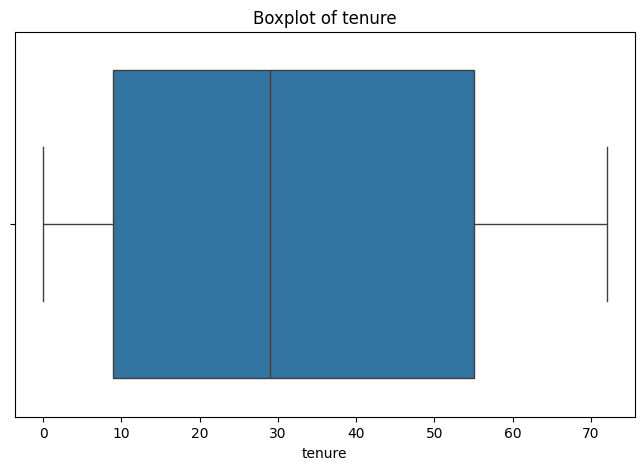

tenure has 0 outliers


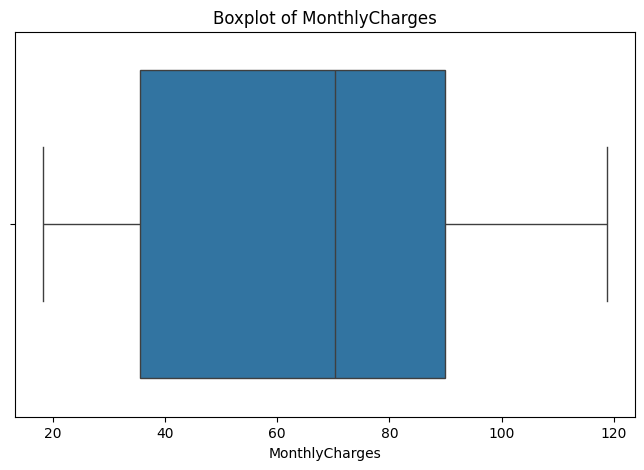

MonthlyCharges has 0 outliers


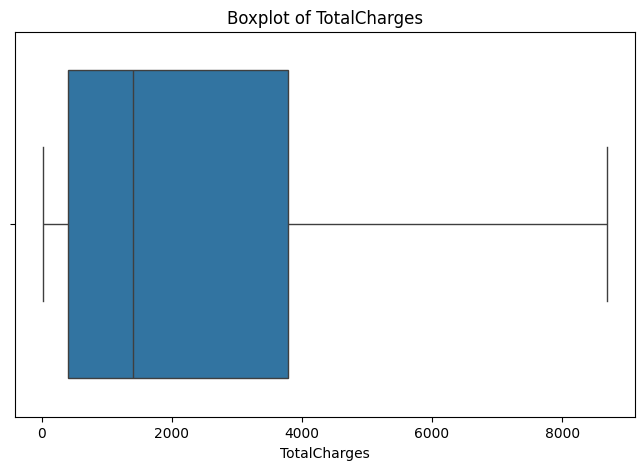

TotalCharges has 0 outliers


In [44]:
for col in num_cal:
    check_outlier(df, col, plot=True)
    

# 9. Correlation

In [45]:
def correlation_analysis(dataframe, corr_th=0.70, plot=False):

    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt

   
    corr_matrix = dataframe.corr(numeric_only=True)

  
    corr_matrix_abs = corr_matrix.abs()

    
    upper_triangle = corr_matrix_abs.where(
        np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool)
    )

    
    to_drop = [
        column for column in upper_triangle.columns
        if any(upper_triangle[column] > corr_th)
    ]

    
    if plot:
        plt.figure(figsize=(12, 10))
        sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
        plt.title("Correlation Matrix")
        plt.show()

    return to_drop

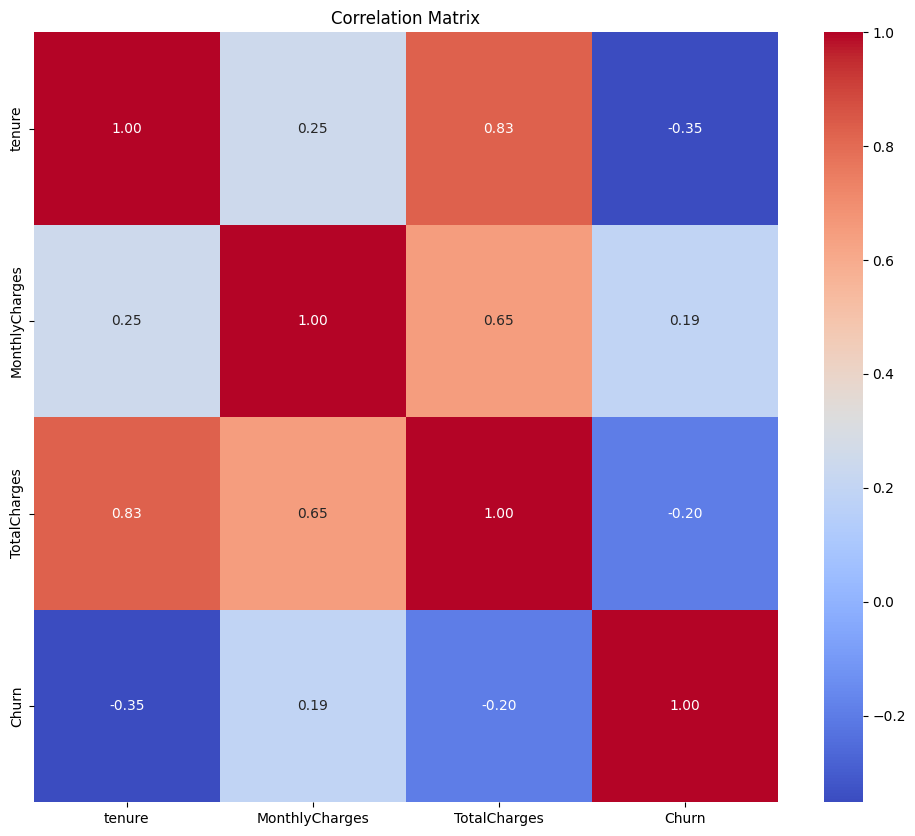

['TotalCharges']

In [46]:
correlation_analysis(df, corr_th=0.70, plot=True)

**TotalCharges and tenure are highly correlated (r = 0.83), indicating potential redundancy**

In [47]:
# numerical columns with churn
def num_vs_target(df, num_col, target="Churn", plot=False):

    print(df.groupby(target)[num_col].mean())
    print("\n")

    if plot:
        import seaborn as sns
        import matplotlib.pyplot as plt

        sns.boxplot(x=target, y=num_col, data=df)
        plt.title(f"{num_col} vs {target}")
        plt.show()

Churn
0   37.570
1   17.979
Name: tenure, dtype: float64




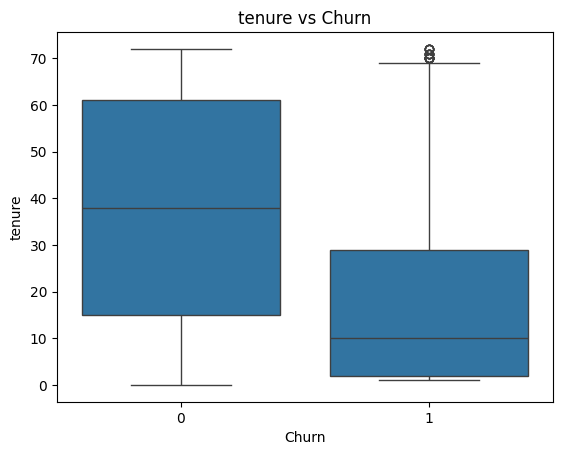

Churn
0   61.265
1   74.441
Name: MonthlyCharges, dtype: float64




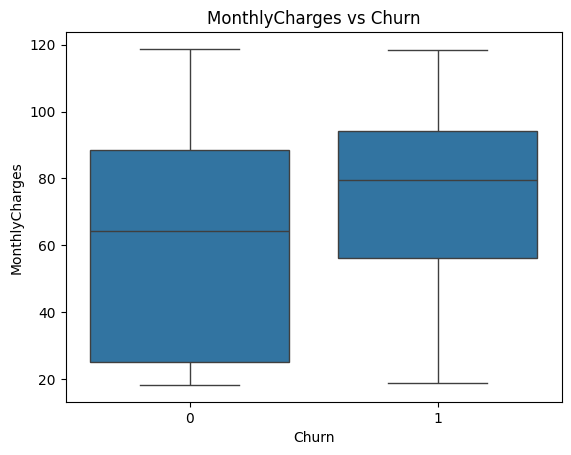

Churn
0   2549.999
1   1531.796
Name: TotalCharges, dtype: float64




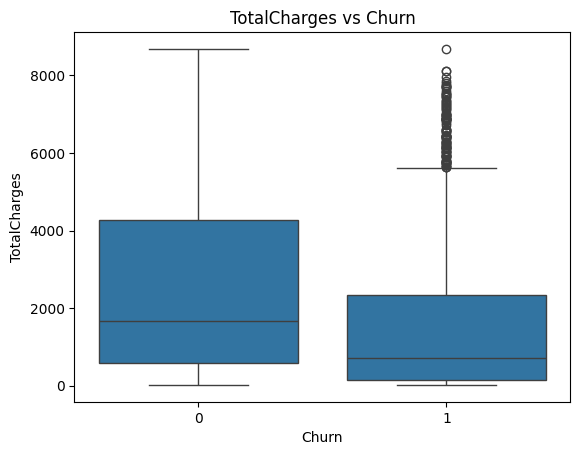

In [48]:
for col in num_cal:
    num_vs_target(df, col , plot=True)

**New customers are more likely to churn. Customers who stay for three years rarely leave. Customers with higher monthly charges tend to churn more, suggesting they may not perceive sufficient value for the price they pay. 
customers who churn have lower total charges simply because they remain with the company for a shorter period. 
TotalCharges is largely driven by tenure and monthly charges (TotalCharges ≈ tenure × MonthlyCharges).**

**Customers who churn tend to have shorter tenure and higher monthly charges, resulting in lower total charges compared to non-churned customers. This suggests that early-stage customers with high pricing plans are more likely to leave.**

In [49]:
def cat_target_summary(df, target, col):

    # 1. Mean of target per category
    target_mean = df.groupby(col)[target].mean()

    # 2. Count per category
    count = df[col].value_counts()

    # 3. Ratio per category
    ratio = 100 * count / len(df)

    # 4. Combine everything
    result = pd.DataFrame({
        "TARGET_MEAN": target_mean,
        "COUNT": count,
        "RATIO_%": ratio
    })

    print("\n", col)
    print(result.sort_values("TARGET_MEAN", ascending=False))
    print("\n" + "-"*50 + "\n")

In [50]:
for col in cat_columns:
    cat_target_summary(df, "Churn", col)


 gender
        TARGET_MEAN  COUNT  RATIO_%
gender                             
Female        0.269   3488   49.524
Male          0.262   3555   50.476

--------------------------------------------------


 SeniorCitizen
               TARGET_MEAN  COUNT  RATIO_%
SeniorCitizen                             
1                    0.417   1142   16.215
0                    0.236   5901   83.785

--------------------------------------------------


 Partner
         TARGET_MEAN  COUNT  RATIO_%
Partner                             
No             0.330   3641   51.697
Yes            0.197   3402   48.303

--------------------------------------------------


 Dependents
            TARGET_MEAN  COUNT  RATIO_%
Dependents                             
No                0.313   4933   70.041
Yes               0.155   2110   29.959

--------------------------------------------------


 PhoneService
              TARGET_MEAN  COUNT  RATIO_%
PhoneService                             
Yes              

**The colums which has good relation with the target 'churn' are :**

Contract 

InternetService 

OnlineSecurity

TechSupport

OnlineBackup

DeviceProtection

PaymentMethod


In [51]:
important_cols = [
    "Contract",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "PaymentMethod"
]

In [52]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(col1, col2):

    table = pd.crosstab(col1, col2)

    chi2 = chi2_contingency(table)[0]

    n = table.sum().sum()

    r, k = table.shape

    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

In [53]:

matrix = pd.DataFrame(
    index=important_cols,
    columns=important_cols
)

for col1 in important_cols:
    for col2 in important_cols:
        matrix.loc[col1, col2] = round(
            cramers_v(df[col1], df[col2]),
            3
        )

print(matrix)

                 Contract InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport PaymentMethod
Contract            1.000           0.207          0.301        0.259            0.297       0.331         0.267
InternetService     0.207           1.000          0.724        0.707            0.707       0.723         0.313
OnlineSecurity      0.301           0.724          1.000        0.718            0.717       0.733         0.305
OnlineBackup        0.259           0.707          0.718        1.000            0.719       0.720         0.283
DeviceProtection    0.297           0.707          0.717        0.719            1.000       0.726         0.287
TechSupport         0.331           0.723          0.733        0.720            0.726       1.000         0.307
PaymentMethod       0.267           0.313          0.305        0.283            0.287       0.307         1.000


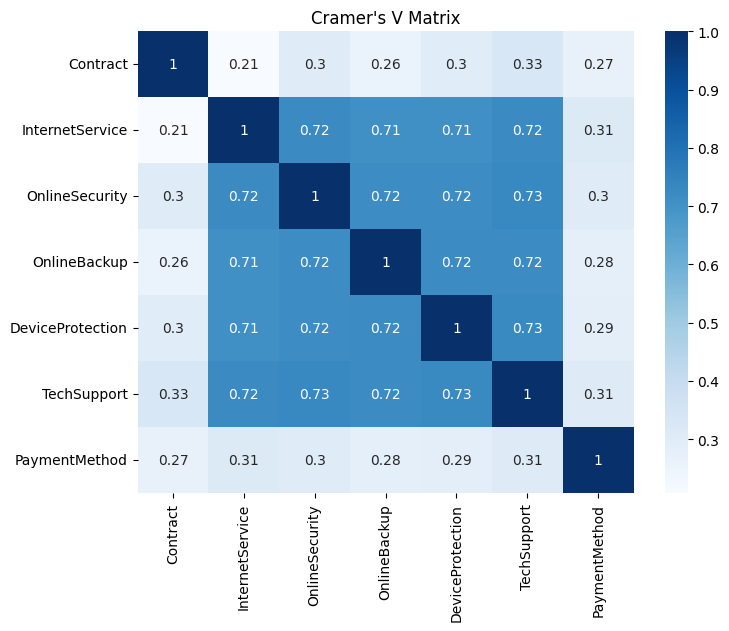

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    matrix.astype(float),
    annot=True,
    cmap="Blues"
)

plt.title("Cramer's V Matrix")
plt.show()


**The high Cramér's V values between InternetService and its add-ons 
(OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport) are expected — customers without 
internet cannot subscribe to these services.**

# ✅ Conclusion & Business Insights

## What the data tells us

After a full exploratory analysis of 7,043 telecom customers, three factors stand out as the strongest predictors of churn:

**1. Contract Type**
Month-to-month customers churn at ~42%. Customers on annual or two-year contracts are significantly more loyal. Encouraging contract upgrades is the highest-leverage retention action.

**2. Tenure**
The first few months are critical. New customers churn at a much higher rate than established ones. Early engagement and onboarding programs could directly reduce churn.

**3. Service Bundling**
Customers with fiber optic internet but no add-on services (security, backup, tech support) churn far more than those with bundled plans. The data suggests these services increase switching costs and perceived value.

---

## What comes next

This EDA provides a solid foundation for a **churn prediction model**.  
The features identified here — `Contract`, `tenure`, `MonthlyCharges`, `InternetService`, `OnlineSecurity`, `TechSupport` — are strong candidates for model input features.

> *Analysis performed by:  — AI Engineering Student, ENSTA Algiers*